In [28]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from joblib import load
from tqdm import tqdm
import warnings

from sklearn.metrics import classification_report
warnings.filterwarnings("ignore")
import glob
import os
from collections import OrderedDict
from src.layers.classifiers import TokenClassifier, MixedClassifier

import h5py
import sys
#import umap
import numpy as np
import matplotlib.pyplot as plt 
from matplotlib import cm


In [29]:
dict = {
    "AGN": 0,
    "QSO": 1,
    "EA": 2,
    "YSO": 3,
    "SNIa": 4,
    "CV/Nova": 5,
    "RRLc": 6,
    "RSCVn": 7,
    "Blazar": 8,
    "SNII": 9,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}

In [30]:

path = '/home/mdelafuente/'#sys.argv[2]

device = torch.device(f"cuda:0" if torch.cuda.is_available() else "cpu")

h5_file = h5py.File(
    f"/home/magdalena/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12//dataset.h5", "r"
)

abs_path = '/home/magdalena/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_baseline0/'
path_args = glob.glob(f"{abs_path}*args*")[0]
print(path_args)
import yaml
with open(path_args, 'r') as file:
    args = yaml.safe_load(file)

/home/magdalena/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_baseline0/args.yaml


In [31]:
print('Initializing models') 
from src.layers.selfsupervised.lightcurve import LightCurveClassifier
model = LightCurveClassifier(**args) 


print('Loading checkpoints')
checkpoint_path_clip = glob.glob(
    f"{abs_path}*my_best_checkpoint*"
) 
print(checkpoint_path_clip[-1])
checkpoint_clip = torch.load(checkpoint_path_clip[-1], map_location=torch.device('cuda:0'))
od_atat = OrderedDict() 

for key in checkpoint_clip["state_dict"].keys(): 
        #print(key)
         
        if 'model' in key:
            od_atat[key.replace("model.", "")] = checkpoint_clip["state_dict"][key]

model.load_state_dict(od_atat,strict=True)

Initializing models
Loading checkpoints
/home/magdalena/pipeline/pipeline/training/lc_classifier_ztf/ATAT_ALeRCE/results/ZTF_ff/LC/class_baseline0/my_best_checkpoint-step=4266.ckpt


<All keys matched successfully>

In [32]:
seed = 0
from src.data.modules.LitData  import LitData


args['general']['data_root'] = 'data/datasets/ZTF_ff/final/LC_MD_FEAT_240627_windows_200_12' 
args['general']['use_sampler'] = False 
args['general']['batch_size'] = 256

pl_datal = LitData(**args['general'])
dataloader = pl_datal.test_dataloader() 
    

KWARGS
{'experiment_type': 'lc', 'experiment_name': 'class_baseline0', 'name_dataset': 'ztf_ff', 'use_lightcurves': True, 'use_lightcurves_err': False, 'use_metadata': False, 'use_features': False, 'use_sampler': False, 'num_epochs': 100, 'patience': 10, 'lr': 0.0001, 'use_cosine_decay': False, 'use_gradient_clipping': False, 'use_mask_detection': False, 'use_time_nondetection': False, 'force_online_opt': False, 'online_opt_tt': False, 'use_QT': False, 'load_pretrained_model': False, 'src_checkpoint': '.', 'use_augmented_dataset': False, 'change_clf': False, 'num_classes': 22}
using set test total of idx : 50501,                 use_lightcurves True, use_metadata False, use_features False,                     use MTA False
list_time_to_eval:  [16, 32, 64, 128, 256, 512, 1024, 2048]
NOT USING SAMPLER FOR DATASET test


In [33]:
target = None
preds_out = None

model.eval().to(device = 'cuda')  

for b1 in tqdm(dataloader):

    #print(b1.keys())
    b1 = {key:value.to(device = 'cuda') for key, value in b1.items()}
    t = b1['labels']
    del b1['labels']
    lc_emb = model(**b1)  
    
    

    preds_out = (
        np.concatenate([preds_out, torch.argmax(lc_emb, axis=1).cpu().numpy()])
        if preds_out is not None
        else torch.argmax(lc_emb, axis=1).cpu().detach().numpy()
    )

    target = (
        np.concatenate([target, t.cpu().detach().numpy()])
        if target is not None
        else t.cpu().numpy()
    )

100%|██████████| 198/198 [00:25<00:00,  7.78it/s]


In [34]:
results = preds_out
classification = classification_report(target, results, target_names=list(dict.keys()),digits = 4)
print(classification)

                precision    recall  f1-score   support

           AGN     0.4210    0.3385    0.3753      3935
           QSO     0.5592    0.5034    0.5298      4108
            EA     0.7454    0.6560    0.6979      4352
           YSO     0.4497    0.4385    0.4441      3295
          SNIa     0.4375    0.2556    0.3227      2175
       CV/Nova     0.4683    0.3498    0.4005      1944
          RRLc     0.6148    0.6540    0.6338      4243
         RSCVn     0.4310    0.4853    0.4566      3124
        Blazar     0.2449    0.2411    0.2430      1709
          SNII     0.2739    0.1567    0.1994      1040
         EB/EW     0.6294    0.6156    0.6224      4615
           LPV     0.7463    0.7079    0.7266      4135
           CEP     0.6506    0.3960    0.4923      3508
         RRLab     0.6988    0.4316    0.5336      4423
Periodic-Other     0.1751    0.4211    0.2473       874
          DSCT     0.2697    0.6037    0.3729      2059
         SNIbc     0.1138    0.2035    0.1459  

In [35]:
data_dict =  classification_report(target, results, target_names=list(dict.keys()),digits = 4, output_dict=True)
classes = data_dict.keys()
f1 = []
for key,value in data_dict.items():
    if key in dict.keys():
        print(key,value)
        f1.append(value['f1-score'])
print(f1)

AGN {'precision': 0.42098609355246525, 'recall': 0.33850063532401525, 'f1-score': 0.37526412170728274, 'support': 3935.0}
QSO {'precision': 0.5592212006489995, 'recall': 0.5034079844206426, 'f1-score': 0.5298488342300793, 'support': 4108.0}
EA {'precision': 0.7454308093994778, 'recall': 0.6560202205882353, 'f1-score': 0.6978733805915425, 'support': 4352.0}
YSO {'precision': 0.4497354497354497, 'recall': 0.4385432473444613, 'f1-score': 0.44406883835279654, 'support': 3295.0}
SNIa {'precision': 0.4374508261211644, 'recall': 0.255632183908046, 'f1-score': 0.3226929773650609, 'support': 2175.0}
CV/Nova {'precision': 0.46831955922865015, 'recall': 0.3497942386831276, 'f1-score': 0.4004711425206125, 'support': 1944.0}
RRLc {'precision': 0.6147540983606558, 'recall': 0.6540183832194202, 'f1-score': 0.6337786913326481, 'support': 4243.0}
RSCVn {'precision': 0.4310491896502701, 'recall': 0.4852752880921895, 'f1-score': 0.4565577473272097, 'support': 3124.0}
Blazar {'precision': 0.24494649227110

In [36]:
transient =  {
    "SNIa": 4,
    "SNII": 9,
    "SNIbc": 16,
    "SLSN": 17,
    "TDE": 18,
    "SNIIb": 19,
    "SNIIn": 20,
    "Microlensing": 21
}
stochastic =  {
    "AGN": 0,
    "QSO": 1,
    "YSO": 3,
    "CV/Nova": 5,
    "Blazar": 8,
}
periodic =  {
    "EA": 2,
    "RRLc": 6,
    "RSCVn": 7,
    "EB/EW": 10,
    "LPV": 11,
    "CEP": 12,
    "RRLab": 13,
    "Periodic-Other": 14,
    "DSCT": 15,
}

In [41]:
trans_f1 = []
stoch_f1 = []
per_f1 = []
for class_key, value in data_dict.items():
    #print(class_key)
    if class_key in dict.keys():
        
        if class_key in transient.keys():
            trans_f1.append(value['f1-score'])
        if class_key in stochastic.keys():
            stoch_f1.append(value['f1-score'])
        if class_key in periodic.keys():
            per_f1.append(value['f1-score'])
print('group eval:')
print('trans',np.mean(trans_f1))
print('stoch',np.mean(stoch_f1))

print('per',np.mean(per_f1))


AGN
QSO
EA
YSO
SNIa
CV/Nova
RRLc
RSCVn
Blazar
SNII
EB/EW
LPV
CEP
RRLab
Periodic-Other
DSCT
SNIbc
SLSN
TDE
SNIIb
SNIIn
Microlensing
accuracy
macro avg
weighted avg
group eval:
trans 0.12092811236676802
stoch 0.39852982062667797
per 0.5314769394664658


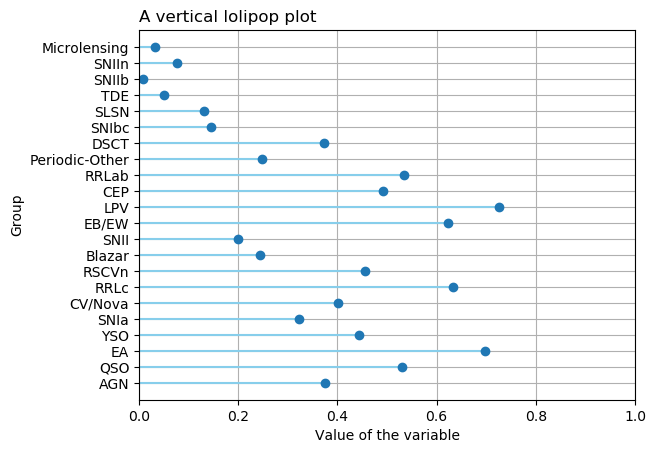

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
 
# Create a dataframe
df = pd.DataFrame({'group':dict.keys(), 'values':f1 })
 
# Reorder it based on the values
ordered_df = df#.sort_values(by='values')
my_range=range(1,len(df.index)+1)
 
# The horizontal plot is made using the hline function
plt.hlines(y=my_range, xmin=0, xmax=ordered_df['values'], color='skyblue')
plt.plot(ordered_df['values'].values, my_range, "o")
 
# Add titles and axis names
plt.yticks(my_range, ordered_df['group'])
plt.title("A vertical lolipop plot", loc='left')
plt.xlabel('Value of the variable')
plt.ylabel('Group')
plt.grid('on')
plt.xlim(0,1)
# Show the plot
plt.show()

['AGN' 'QSO' 'EA' 'YSO' 'SNIa' 'CV/Nova' 'RRLc' 'RSCVn' 'Blazar' 'SNII'
 'EB/EW' 'LPV' 'CEP' 'RRLab' 'Periodic-Other' 'DSCT' 'SNIbc' 'SLSN' 'TDE'
 'SNIIb' 'SNIIn' 'Microlensing']
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21]
Normalized confusion matrix


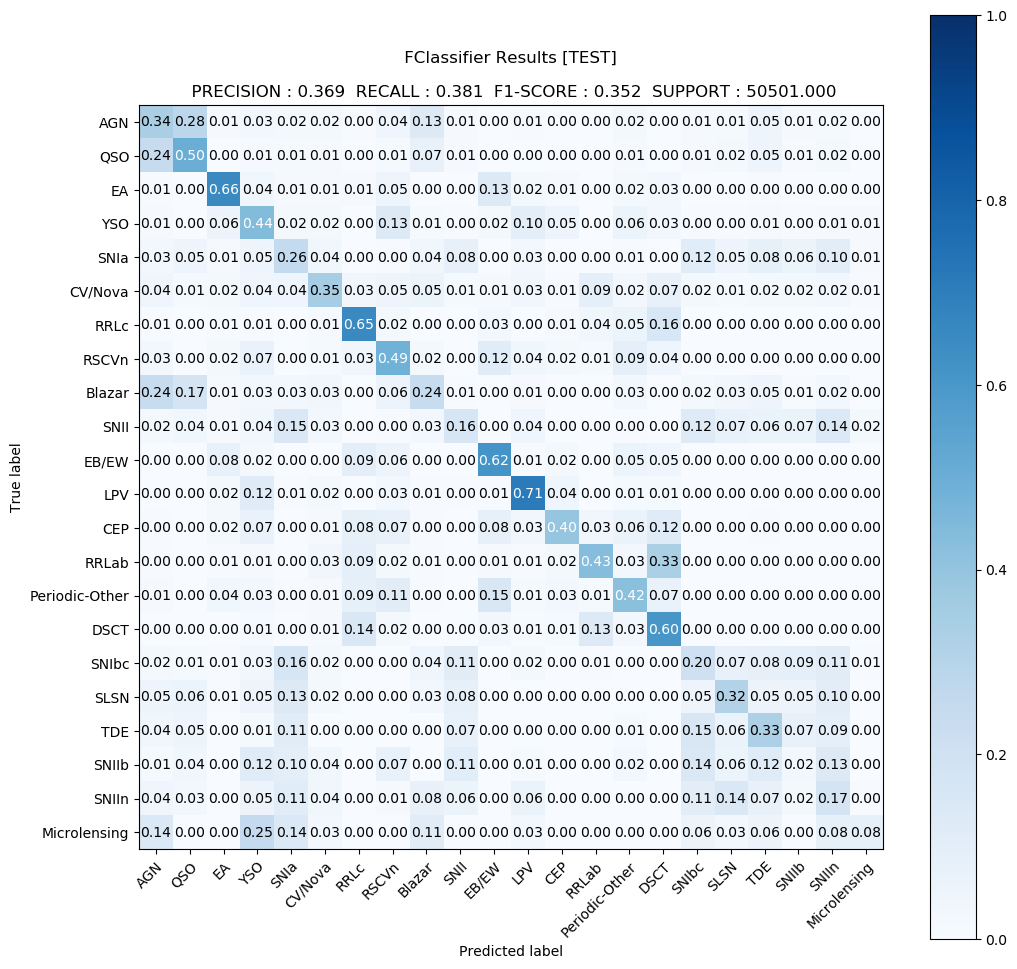

In [16]:
import matplotlib.pyplot as plt
from src.utils.plottinglib import elasticc_confusion_matrix
out_metrics_balto = classification_report(
    target, results, target_names=list(dict.keys()), output_dict=True
)["macro avg"]

template_balto = ""

for key in out_metrics_balto.keys():
    template_balto += " {} : {:.3f} ".format(key.upper(), out_metrics_balto[key])
fig, axes = plt.subplots(1, 1, figsize=(12, 12))
elasticc_confusion_matrix(
    y_true=np.array(target).astype(int),
    y_pred=np.array(results).astype(int),
    classes= np.array(list(dict.keys())),
    ax=axes,
    normalize=True,
    title=f" FClassifier Results [TEST] \n\n {template_balto}",
)